# 24. Feature Scaling - Standardization 

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

In [6]:
df = pd.read_csv('Social_Network_Ads.csv')

In [8]:
df=df.iloc[:,2:] 

In [35]:
df


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [36]:
df.sample(5)

,Age,EstimatedSalary,Purchased
384,57,33000,1
72,20,23000,0
33,28,44000,0
394,39,59000,0
356,54,70000,1


## Train Test Split 

In [40]:
# Always split the data into train and test set before proceeding 

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.3,random_state=0)
X_train.shape , X_test.shape

((280, 2), (120, 2))

## Standard Scaler

In [45]:
# Standard Scaler class is used for transforming the column i.e. for Standardization  

In [47]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

# fit the scalar to the train set , it will learn the parameters 
scaler.fit(X_train) 

# transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test) 

In [49]:
scaler.mean_ 

array([3.78642857e+01, 6.98071429e+04])

In [51]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [53]:
X_train.mean()

Age                   37.864286
EstimatedSalary    69807.142857
dtype: float64

In [55]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns) 

In [57]:
X_train_scaled

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047
...,...,...
275,0.993704,-1.151185
276,-0.869053,-0.775237
277,-0.182774,-0.514966
278,-1.065133,-0.457127


In [59]:
X_train_scaled.mean()

Age                3.489272e-17
EstimatedSalary    6.344132e-17
dtype: float64

In [61]:
np.round(X_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [71]:
np.round(X_train_scaled.describe(),1) 
# We can see here that the mean and standard deviation are 0 and 1 for both the columns 

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of scaling 

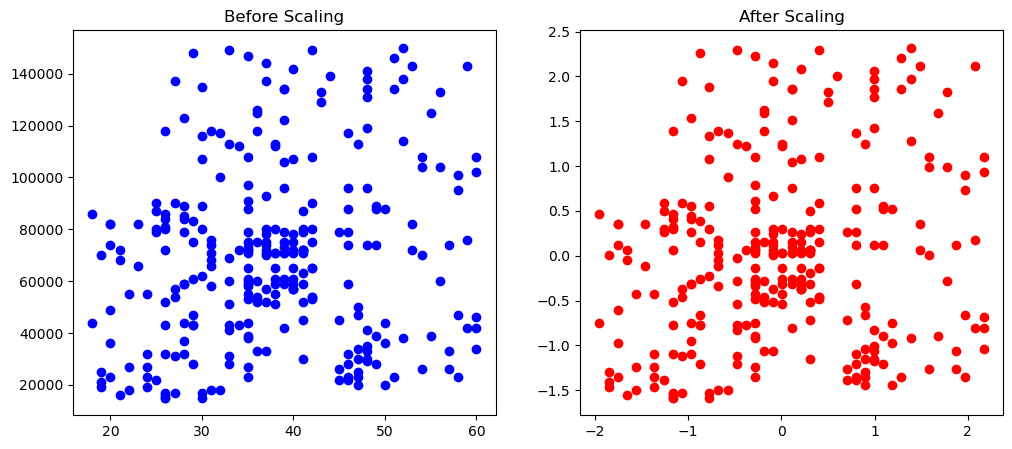

In [75]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5)) 

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'], color='blue')
ax1.set_title('Before Scaling') 
 
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
ax2.set_title('After Scaling')

plt.show()

# We can see that the data after scaling has been centered around the origin, without changing the shape of graph 

C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

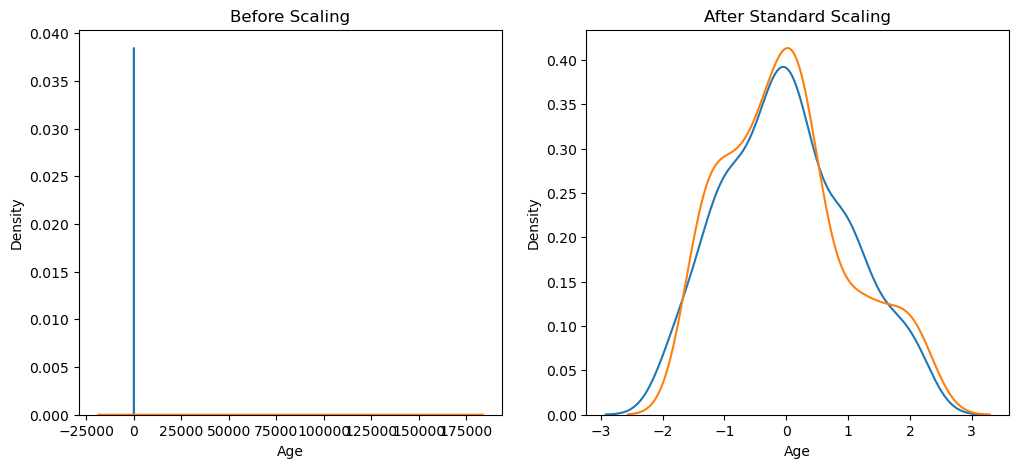

In [77]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5)) 

# before scaling 
ax1.set_title('Before Scaling') 
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'],ax=ax1) 

# after scaling 
ax2.set_title('After Standard Scaling') 
sns.kdeplot(X_train_scaled["Age"],ax=ax2) 
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=ax2) 
plt.show() 

# Since there is a large gap between age and salary, we can see that the pdf is almost straight 
# On the other hand, after scaling we got a good pdf curve 

## Comparison of Distributions 

C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Subham\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<function matplotlib.pyplot.show(close=None, block=None)>

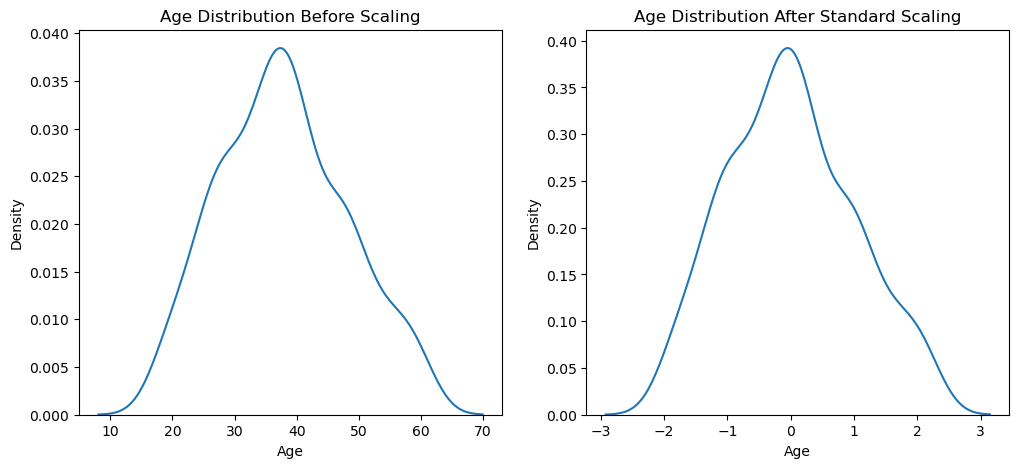

In [79]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5)) 

# before scaling 
ax1.set_title("Age Distribution Before Scaling") 
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling 
ax2.set_title("Age Distribution After Standard Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2) 
plt.show

## Why Scaling is important 

## Logistic Regression

In [82]:
from sklearn.linear_model import LogisticRegression 

In [84]:
lr = LogisticRegression()
lr_scaled = LogisticRegression() 

In [86]:
lr.fit(X_train,y_train) 
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [124]:
y_pred = lr.predict(X_test) 
y_pred_scaled = lr_scaled.predict(X_test_scaled) 

In [90]:
from sklearn.metrics import accuracy_score 

In [92]:
print("Actual", accuracy_score(y_test,y_pred)) 
print("Scaled", accuracy_score(y_test,y_pred_scaled)) 

Actual 0.6583333333333333
Scaled 0.8666666666666667


## Decision Tree 

In [94]:
from sklearn.tree import DecisionTreeClassifier 

In [96]:
dt = DecisionTreeClassifier() 
dt_scaled = DecisionTreeClassifier() 

In [128]:
dt.fit(X_train,y_train) 
dt_scaled.fit(X_train_scaled,y_train) 

DecisionTreeClassifier()

In [130]:
y_pred = dt.predict(X_test) 
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [132]:
print("Actual", accuracy_score(y_test, y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.8760330578512396
Scaled 0.8760330578512396


In [134]:
df.describe() 

,Age,EstimatedSalary,Purchased
count,403.000000,403.000000,403.000000
mean,37.846154,70714.640199,0.359801
std,11.255343,37959.790969,0.480539
min,5.000000,1000.000000,0.000000
25%,29.500000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,95.000000,350000.000000,1.000000


## Effect of outlier 

### Introducing outliers in the data

In [136]:
df = pd.concat([df, pd.DataFrame({'Age': [5, 90, 95], 'EstimatedSalary': [1000, 250000, 350000], 'Purchased': [0, 1, 1]})], ignore_index=True) 

In [138]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,250000,1
402,95,350000,1
403,5,1000,0
404,90,250000,1


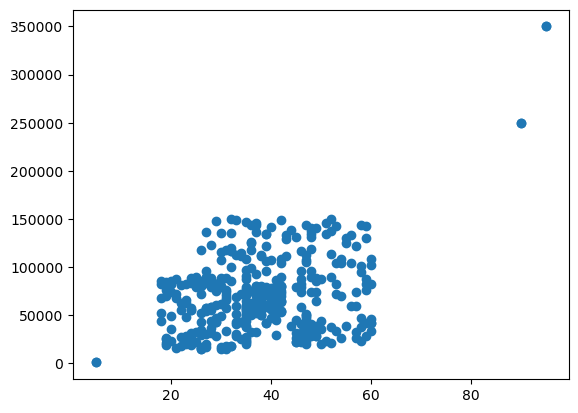

In [147]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [142]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0 ) 
X_train.shape , X_test.shape

((284, 2), (122, 2))

In [116]:
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler() 

# fit the scaler to the train set, it will learn the parameters 
scaler.fit(X_train) 

# transform train and test sets 
X_train_scaled = scaler.transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

In [118]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns) 
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

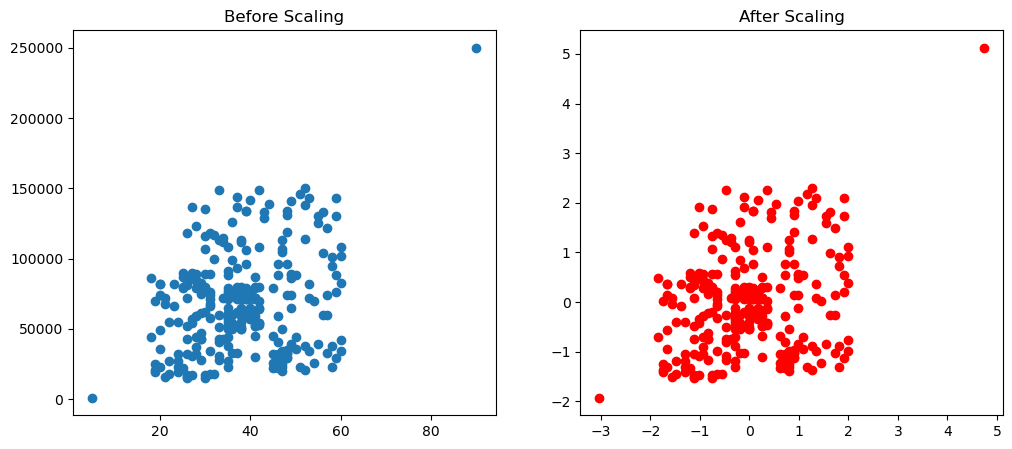

In [120]:
fig, (ax1, ax2) =  plt.subplots(ncols=2, figsize=(12,5)) 
ax1.scatter(X_train['Age'], X_train['EstimatedSalary']) 
ax1.set_title("Before Scaling") 
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red') 
ax2.set_title("After Scaling") 
plt.show()